In [2]:
!pip install tensorflow scikit-learn shap statsmodels matplotlib pandas numpy boruta

In [3]:
# =====================================================================
# [Step 0] 환경 설정 및 필수 라이브러리 로드
# =====================================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, SimpleRNN, Input, Dropout
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import shap
from boruta import BorutaPy
import matplotlib.pyplot as plt
import os
import warnings
import itertools

# 불필요한 경고문구 숨김
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

In [30]:
# =====================================================================
# [Step 0 & 1] 가상 오염원 시료 데이터 생성 함수 및 환경 설정
# =====================================================================
def generate_virtual_data_advanced(n_samples=5000):
    np.random.seed(2026)
    
    # 1. 기여율 생성 (Dirichlet 분표를 활용하여 기여율의 합이 1이 되도록 설정)
    props = np.random.dirichlet([1, 1, 1, 1, 1], n_samples)
    prop_names = ["p_Manure", "p_Sewage", "p_Fertilizer", "p_Soil", "p_Rain"]
    
    # 2. 오염원별 평균 및 표준편차 설정
    src_mean = np.array([
        [19.80, 5.30], # Manure
        [13.36, 1.96], # Sewage
        [0.87, 14.39], # Fertilizer
        [2.16, 3.52],  # Soil
        [1.71, 45.81]  # Rain
    ])
    
    src_sd = np.array([
        [3.26, 4.03],
        [1.91, 2.69],
        [0.33, 5.18],
        [1.21, 4.22],
        [1.56, 5.73]
    ])
    
    # 3. 혼합 법칙 적용 및 데이터 생성
    M_mean = np.dot(props, src_mean)
    M_var = np.dot(props**2, src_sd**2)
    
    noise = np.random.randn(n_samples, 2)
    features = M_mean + noise * np.sqrt(M_var)
    col_names = ["d15N", "d18O"]
    
    df_features = pd.DataFrame(features, columns=col_names)
    df_props = pd.DataFrame(props, columns=prop_names)
    
    # 4. 표준화 수행
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df_features)
    df_features_scaled = pd.DataFrame(features_scaled, columns=col_names)
    
    return df_features, df_features_scaled, df_props, scaler

# 데이터 생성 및 분리
df_raw, df_scaled, df_props, global_scaler = generate_virtual_data_advanced(5000)

X_all = df_scaled.values
Y_all = df_props.values

# 80:20 분리
np.random.seed(2026)
indices = np.random.permutation(len(X_all))
train_size = int(0.8 * len(X_all))

train_idx, test_idx = indices[:train_size], indices[train_size:]
X_train, X_test = X_all[train_idx], X_all[test_idx]
Y_train, Y_test = Y_all[train_idx], Y_all[test_idx]

In [ ]:
# =====================================================================
# [Step 1-1] SMOTE 적용을 통한 데이터 불균형 해소 (선택적 프로세스)
# =====================================================================
print("\n=== [Step 1-1. SMOTE 기반 훈련 데이터 불균형 해소 (선택적 적용)] ===")
# from imblearn.over_sampling import SMOTE  # 필요한 경우 활성화

def apply_smote_regression(X_mat, Y_mat, k_neighbors=5):
    dominant_class = np.argmax(Y_mat, axis=1)
    XY_combined = np.hstack([X_mat, Y_mat])
    
    # smote = SMOTE(k_neighbors=k_neighbors, random_state=2026)
    # XY_resampled, _ = smote.fit_resample(XY_combined, dominant_class)
    XY_resampled = XY_combined # 현재 가상환경 데이터이므로 임시로 원본 반환
    
    n_x_cols = X_mat.shape[1]
    new_X = XY_resampled[:, :n_x_cols]
    new_Y = XY_resampled[:, n_x_cols:]
    
    new_Y = np.clip(new_Y, 0, None)
    pred_sum = np.sum(new_Y, axis=1, keepdims=True)
    new_Y_normalized = np.divide(new_Y, np.where(pred_sum == 0, 1, pred_sum))
    
    return new_X, new_Y_normalized

X_train_smote, Y_train_smote = apply_smote_regression(X_train, Y_train, k_neighbors=5)
print(f"SMOTE 적용 전 Train 샘플 수: {X_train.shape[0]}")
print(f"SMOTE 적용 후 Train 샘플 수: {X_train_smote.shape[0]}")

In [31]:
# =====================================================================
# [Step 2] AI 모델 5종 (DNN, CNN, LSTM, RNN, PINNs) 구축 및 학습/예측 함수
# =====================================================================
# [알고리즘 원리 설명]
# 1. DNN (Deep Neural Network): 가장 기본적인 다층 퍼셉트론. 입력 특성과 출력 기여율 간의 복잡한 비선형 매핑을 학습합니다.
# 2. CNN (Convolutional Neural Network): 1D-Conv를 통해 화학적/동위원소 특성들 사이의 인접한 패턴이나 국소적 특징을 추출합니다.
# 3. LSTM (Long Short-Term Memory): 장기 의존성을 학습하는 RNN의 변형으로, 특성들 간의 복잡하고 깊은 상호작용을 포착합니다.
# 4. RNN (Recurrent Neural Network): 순환 신경망. 본래 시계열에 쓰이나, 입력 벡터를 하나의 시퀀스로 보고 변수 간 전이 관계를 학습합니다.
# 5. PINNs (Physics-Informed Neural Networks): 순수 데이터 기반 학습에 '물리적 법칙'을 강제합니다. 여기서는 오염원 기여율의 합이 
#    반드시 1 (100%)이 되어야 한다는 질량 보존(Mass Balance) 법칙을 Custom Loss 형태로 네트워크에 주입합니다.

def pinn_loss(y_true, y_pred):
    """PINNs 모델을 위한 Custom Loss 함수 (MSE + 물리적 법칙 제약조건)"""
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    # 제약조건: 모든 오염원 기여율의 합은 1이 되어야 함
    mass_balance_penalty = tf.reduce_mean(tf.square(tf.reduce_sum(y_pred, axis=1) - 1.0))
    return mse_loss + (0.5 * mass_balance_penalty) # 물리법칙 위반 시 패널티 부여

def build_model(method, input_dim, output_dim):
    model = Sequential()
    if method == "DNN" or method == "PINN":
        model.add(Input(shape=(input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(32, activation='relu'))
    elif method == "CNN":
        model.add(Input(shape=(input_dim, 1)))
        model.add(Conv1D(filters=32, kernel_size=2, activation='relu'))
        model.add(Flatten())
        model.add(Dense(32, activation='relu'))
    elif method == "LSTM":
        model.add(Input(shape=(1, input_dim)))
        model.add(LSTM(32, activation='relu'))
    elif method == "RNN":
        model.add(Input(shape=(1, input_dim)))
        model.add(SimpleRNN(32, activation='relu')) # RNN 레이어 추가
        
    model.add(Dense(output_dim, activation='softmax'))
    
    # PINN일 경우 물리 법칙이 결합된 Custom Loss 사용, 그 외는 일반 MSE 사용
    if method == "PINN":
        model.compile(optimizer='adam', loss=pinn_loss)
    else:
        model.compile(optimizer='adam', loss='mse')
        
    return model

def reshape_for_model(method, X):
    if method == "CNN":
        return X.reshape(X.shape[0], X.shape[1], 1)
    elif method in ["LSTM", "RNN"]:
        return X.reshape(X.shape[0], 1, X.shape[1])
    return X # DNN, PINN

def train_and_predict_dl(method, X_tr, Y_tr, X_te, epochs=30, batch_size=32):
    X_tr_reshaped = reshape_for_model(method, X_tr)
    X_te_reshaped = reshape_for_model(method, X_te)
    
    model = build_model(method, input_dim=X_tr.shape[1], output_dim=Y_tr.shape[1])
    model.fit(X_tr_reshaped, Y_tr, epochs=epochs, batch_size=batch_size, verbose=0)
    
    predictions = model.predict(X_te_reshaped, verbose=0)
    return predictions, model

In [32]:
# =====================================================================
# [Step 3] 전체 모델 실행 및 성능 평가
# =====================================================================
def calc_metrics(true, pred):
    epsilon = 1e-10
    mae = np.mean(np.abs(true - pred))
    rmse = np.sqrt(np.mean((true - pred)**2))
    mape = np.mean(np.abs((true - pred) / (true + epsilon))) * 100
    
    numerator = np.sum((true - pred)**2)
    denominator = np.sum((np.abs(pred - np.mean(true)) + np.abs(true - np.mean(true)))**2)
    ioa = 1 - (numerator / (denominator + epsilon))
    return mae, rmse, mape, ioa

# RNN과 PINN 추가
ai_methods = ["DNN", "CNN", "LSTM", "RNN", "PINN"]
trained_models = {}

print("\n=== [Step 3. 모델별 성능 평가 (MAE, RMSE, MAPE, IOA)] ===")
for m in ai_methods:
    preds, model = train_and_predict_dl(m, X_train, Y_train, X_test, epochs=50)
    trained_models[m] = model
    mae, rmse, mape, ioa = calc_metrics(Y_test, preds)
    print(f"{m:<12} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | IOA: {ioa:.4f}")


=== [Step 3. 모델별 성능 평가 (MAE, RMSE, MAPE, IOA)] ===
DNN          | MAE: 0.0883 | RMSE: 0.1174 | MAPE: 306.07% | IOA: 0.7956
CNN          | MAE: 0.0880 | RMSE: 0.1169 | MAPE: 307.78% | IOA: 0.7956
LSTM         | MAE: 0.0880 | RMSE: 0.1169 | MAPE: 303.69% | IOA: 0.7972
RNN          | MAE: 0.0881 | RMSE: 0.1173 | MAPE: 307.77% | IOA: 0.7960
PINN         | MAE: 0.0883 | RMSE: 0.1174 | MAPE: 304.34% | IOA: 0.7981


In [33]:
# =====================================================================
# [Step 3-1] K-fold-crossvalidation 기반 통합 성능 평가
# =====================================================================
print("\n=== [Step 3-1. 5-Fold Cross-Validation 통합 성능 평가] ===")
kf = KFold(n_splits=5, shuffle=True, random_state=2026)

for m in ai_methods:
    fold_metrics = []
    for train_index, test_index in kf.split(X_all):
        X_tr_cv, X_te_cv = X_all[train_index], X_all[test_index]
        Y_tr_cv, Y_te_cv = Y_all[train_index], Y_all[test_index]
        
        cv_preds, _ = train_and_predict_dl(m, X_tr_cv, Y_tr_cv, X_te_cv, epochs=30)
        fold_metrics.append(calc_metrics(Y_te_cv, cv_preds))
        
    avg_metrics = np.mean(fold_metrics, axis=0)
    print(f"[CV] {m:<8} | MAE: {avg_metrics[0]:.4f} | RMSE: {avg_metrics[1]:.4f} | MAPE: {avg_metrics[2]:.2f}% | IOA: {avg_metrics[3]:.4f}")


=== [Step 3-1. 5-Fold Cross-Validation 통합 성능 평가] ===
[CV] DNN      | MAE: 0.0888 | RMSE: 0.1175 | MAPE: 667.93% | IOA: 0.8003
[CV] CNN      | MAE: 0.0889 | RMSE: 0.1177 | MAPE: 666.57% | IOA: 0.8003
[CV] LSTM     | MAE: 0.0888 | RMSE: 0.1176 | MAPE: 665.65% | IOA: 0.8003
[CV] RNN      | MAE: 0.0888 | RMSE: 0.1175 | MAPE: 676.42% | IOA: 0.8005
[CV] PINN     | MAE: 0.0889 | RMSE: 0.1177 | MAPE: 679.73% | IOA: 0.7982


In [34]:
# =====================================================================
# [Step 4] 미지 시료 분석 프로세스 (AI 앙상블 통합)
# =====================================================================

# 사용 모델 재정립 (표준화된 전체 데이터 사용)
def calc_metrics(true, pred):
    epsilon = 1e-10
    mae = np.mean(np.abs(true - pred))
    rmse = np.sqrt(np.mean((true - pred)**2))
    mape = np.mean(np.abs((true - pred) / (true + epsilon))) * 100
    
    numerator = np.sum((true - pred)**2)
    denominator = np.sum((np.abs(pred - np.mean(true)) + np.abs(true - np.mean(true)))**2)
    ioa = 1 - (numerator / (denominator + epsilon))
    return mae, rmse, mape, ioa

ai_methods = ["DNN", "CNN", "LSTM", "RNN", "PINN"]
trained_models = {}

for m in ai_methods:
    preds, model = train_and_predict_dl(m, X_all, Y_all, X_all, epochs=50)
    trained_models[m] = model
    mae, rmse, mape, ioa = calc_metrics(Y_all, preds)
    print(f"{m:<12} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | IOA: {ioa:.4f}")

DNN          | MAE: 0.0882 | RMSE: 0.1167 | MAPE: 648.72% | IOA: 0.8064
CNN          | MAE: 0.0883 | RMSE: 0.1169 | MAPE: 653.86% | IOA: 0.8056
LSTM         | MAE: 0.0886 | RMSE: 0.1170 | MAPE: 668.55% | IOA: 0.8012
RNN          | MAE: 0.0884 | RMSE: 0.1169 | MAPE: 669.75% | IOA: 0.8031
PINN         | MAE: 0.0886 | RMSE: 0.1172 | MAPE: 659.89% | IOA: 0.8019


In [35]:
# ---------------------------------------------------------------------
# [Step 4-1] 임의의 단일 시료(Single Sample) 예측 및 앙상블
# ---------------------------------------------------------------------
print("\n=== [4-1. 단일 임의 시료 기반 알고리즘별 & 앙상블 추정 결과] ===")
single_matrix = np.array([[12.5, 3.2]])
single_matrix_scaled = global_scaler.transform(single_matrix)

single_preds_all = []

for m in ai_methods:
    X_single = reshape_for_model(m, single_matrix_scaled)
    single_pred = trained_models[m].predict(X_single, verbose=0)
    single_preds_all.append(single_pred)
    print(f"[{m:<4}]: {np.round(single_pred[0], 4)}")

single_preds_stack = np.vstack(single_preds_all)
ens_single_mean = np.mean(single_preds_stack, axis=0)
ens_single_sd = np.std(single_preds_stack, axis=0)

print(f"\n[Ensemble Mean]: {np.round(ens_single_mean, 4)}")
print(f"[Ensemble SD  ]: {np.round(ens_single_sd, 4)}")


=== [4-1. 단일 임의 시료 기반 알고리즘별 & 앙상블 추정 결과] ===
[DNN ]: [0.3122 0.4258 0.09   0.1433 0.0287]
[CNN ]: [0.3046 0.4184 0.0933 0.1523 0.0314]
[LSTM]: [0.3077 0.4205 0.0855 0.1582 0.0281]
[RNN ]: [0.307  0.4149 0.0964 0.1492 0.0325]
[PINN]: [0.2869 0.4657 0.0904 0.1283 0.0286]

[Ensemble Mean]: [0.3037 0.429  0.0911 0.1463 0.0299]
[Ensemble SD  ]: [0.0087 0.0187 0.0036 0.0102 0.0017]


In [36]:
# ---------------------------------------------------------------------
# [Step 4-2] CSV 미지 시료 배치 분석 및 앙상블 결과 통합 저장
# ---------------------------------------------------------------------
cat_header_42 = "\n=== [4-2. CSV 미지 시료 배치 분석 및 앙상블 통합 저장] ==="
csv_path = "C:/Users/User/Desktop/compare2024_consumer_April_ML_AI.csv" # 경로 확인 요망

if os.path.exists(csv_path):
    print(cat_header_42)
    unknown_samples_df = pd.read_csv(csv_path)
    unknown_matrix = unknown_samples_df[["d15N", "d18O"]].values
    unknown_matrix_scaled = global_scaler.transform(unknown_matrix)
    
    batch_preds_dict = {}

    for m in ai_methods:
        X_batch = reshape_for_model(m, unknown_matrix_scaled)
        batch_preds = trained_models[m].predict(X_batch, verbose=0)
        batch_preds_dict[m] = batch_preds
        
        pred_df = pd.DataFrame(batch_preds, columns=df_props.columns)
        final_output = pd.concat([unknown_samples_df, pred_df.round(4)], axis=1)
        final_output.to_csv(f"Final_Contribution_{m}.csv", index=False)
        print(f"[{m}] 모델 결과 저장 완료")
        
    all_batch_array = np.array([batch_preds_dict[m] for m in ai_methods])
    ens_batch_mean = np.mean(all_batch_array, axis=0)
    ens_batch_sd = np.std(all_batch_array, axis=0)
    
    ens_mean_df = pd.DataFrame(ens_batch_mean, columns=[f"EnsMean_{c}" for c in df_props.columns])
    ens_sd_df = pd.DataFrame(ens_batch_sd, columns=[f"EnsSD_{c}" for c in df_props.columns])
    
    ensemble_final_output = pd.concat([unknown_samples_df, ens_mean_df.round(4), ens_sd_df.round(4)], axis=1)
    ensemble_final_output.to_csv("Final_Contribution_AI_Ensemble.csv", index=False)
    print("\n[완료] 5종 AI 모델의 통합 앙상블 CSV가 생성되었습니다.")
else:
    print(f"\n[알림] '{csv_path}' 파일이 없어 4-2 단계를 건너뜁니다.")


=== [4-2. CSV 미지 시료 배치 분석 및 앙상블 통합 저장] ===
[DNN] 모델 결과 저장 완료
[CNN] 모델 결과 저장 완료
[LSTM] 모델 결과 저장 완료
[RNN] 모델 결과 저장 완료
[PINN] 모델 결과 저장 완료

[완료] 5종 AI 모델의 통합 앙상블 CSV가 생성되었습니다.


In [ ]:
# ---------------------------------------------------------------------
# [Step 4-3] 고정(임의)효과 기반 오염원 기여율 패턴 분석 및 저장
# ---------------------------------------------------------------------
cat_header_43 = "\n=== [4-3. 고정/임의효과(그룹별) 오염원 기여율 패턴 분석] ==="
target_file = "C:/Users/User/Desktop/compare2024_consumer_April_ML_AI.csv"

if os.path.exists(target_file):
    print(cat_header_43)
    sample_df = pd.read_csv(target_file)
    sample_matrix = sample_df[["d15N", "d18O", "Cl", "NO3N"]].values
    sample_matrix_scaled = global_scaler.transform(sample_matrix)
    
    target_effects = ["month", "spot"]
    source_cols = df_props.columns.tolist()
    all_model_preds = {}

    for m in ai_methods:
        X_effect = reshape_for_model(m, sample_matrix_scaled)
        effect_preds = trained_models[m].predict(X_effect, verbose=0)
        all_model_preds[m] = effect_preds
        
        pred_df_individual = pd.DataFrame(effect_preds, columns=source_cols)
        combined_df = pd.concat([sample_df, pred_df_individual], axis=1)
        
        for effect in target_effects:
            if effect in combined_df.columns:
                summary_df = combined_df.groupby(effect)[source_cols].agg(['mean', 'std']).reset_index()
                summary_df.columns = [effect] + [f"{col}_{stat}" for col, stat in summary_df.columns[1:]]
                summary_filename = f"Summary_Contribution_{m}_by_{effect}.csv"
                summary_df.round(4).to_csv(summary_filename, index=False)
                print(f"[{m:<4}] {effect}별 그룹 통계 저장 완료")

    print("\n--- [앙상블 통합 분석 시작] ---")
    ensemble_preds_array = np.mean(list(all_model_preds.values()), axis=0)
    ens_pred_df = pd.DataFrame(ensemble_preds_array, columns=source_cols)
    ens_combined_df = pd.concat([sample_df, ens_pred_df], axis=1)
    
    for effect in target_effects:
        if effect in ens_combined_df.columns:
            ens_summary_df = ens_combined_df.groupby(effect)[source_cols].agg(['mean', 'std']).reset_index()
            ens_summary_df.columns = [effect] + [f"{col}_{stat}" for col, stat in ens_summary_df.columns[1:]]
            ens_summary_filename = f"Summary_Contribution_Ensemble_by_{effect}.csv"
            ens_summary_df.round(4).to_csv(ens_summary_filename, index=False)
            print(f"[ENS ] {effect}별 그룹 통계 저장 완료")
else:
    print(f"\n[알림] '{target_file}' 파일이 없어 4-3 단계를 건너뜁니다.")

In [37]:
# =====================================================================
# [Step 5] 통합 XAI (SHAP, Boruta, H-statistic) 분석
# =====================================================================
print("\n=== [5. 모든 모델 및 오염원에 대한 통합 XAI 분석 시작] ===")
X_explain_raw = X_all[:50] 

feature_names = ["d15N", "d18O"]
source_names = df_props.columns


=== [5. 모든 모델 및 오염원에 대한 통합 XAI 분석 시작] ===


In [38]:
# ---------------------------------------------------------------------
# 5-1. SHAP (Shapley Additive exPlanations)
# [원리]: 게임 이론을 바탕으로 각 피처가 특정 예측값에 기여한 정도를 분배합니다.
# 어떤 변수가 예측값을 높였는지, 낮췄는지 방향과 크기를 개별 샘플마다 설명 가능합니다.
# ---------------------------------------------------------------------
print("-> SHAP 계산 진행 중...")
all_shap_results = []

for m in ai_methods:
    model = trained_models[m]
    def predict_wrapper(x):
        return model.predict(reshape_for_model(m, x), verbose=0)
    
    explainer = shap.KernelExplainer(predict_wrapper, X_explain_raw[:10])
    shap_values = explainer.shap_values(X_explain_raw, silent=True)
    
    for s_idx, s_name in enumerate(source_names):
        imp_scores = np.mean(np.abs(shap_values[s_idx]), axis=0)
        for f_idx, f_name in enumerate(feature_names):
            all_shap_results.append({
                "Method": m, "Source": s_name, "Feature": f_name, "SHAP_Importance": imp_scores[f_idx]
            })

-> SHAP 계산 진행 중...


In [39]:
# ---------------------------------------------------------------------
# 5-2. Boruta Algorithm
# [원리]: 원본 특성의 복제본(Shadow Features)을 무작위로 섞어 랜덤 포레스트를 학습시킨 뒤,
# 원본 특성의 중요도가 섀도우 특성의 최대 중요도보다 통계적으로 유의하게 높은지 평가하여
# '진짜 중요한 변수'를 선별(Selection)하는 전역적 중요도 평가 기법입니다.
# ---------------------------------------------------------------------
print("-> Boruta 특성 선택 진행 중...")
boruta_results = []
for s_idx, s_name in enumerate(source_names):
    # 타겟(오염원)별로 1D Target 배열 추출
    Y_target = Y_all[:500, s_idx] # 계산 효율을 위해 샘플 제한
    X_target = X_all[:500, :]
    
    rf = RandomForestRegressor(n_jobs=-1, max_depth=5, random_state=2026)
    # BorutaPy 초기화 및 학습
    feat_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=2026)
    feat_selector.fit(X_target, Y_target)
    
    for f_idx, f_name in enumerate(feature_names):
        boruta_results.append({
            "Source": s_name,
            "Feature": f_name,
            "Boruta_Support": feat_selector.support_[f_idx],      # True면 중요 특성 채택
            "Boruta_Ranking": feat_selector.ranking_[f_idx]       # 1위일수록 중요
        })
boruta_df = pd.DataFrame(boruta_results)
boruta_df.to_csv("Total_XAI_Boruta_Results.csv", index=False)

-> Boruta 특성 선택 진행 중...


In [40]:
# ---------------------------------------------------------------------
# 5-3. H-statistic (Friedman's H-statistic)
# [원리]: 특성들 간의 상호작용(Interaction) 강도를 정량화합니다.
# 부분 의존성(Partial Dependence)을 활용하여, 두 변수가 결합했을 때의 효과가
# 각각 독립적으로 작용했을 때의 합과 얼마나 차이가 나는지 분산을 통해 측정합니다.
# ---------------------------------------------------------------------
print("-> H-statistic 2-Way 상호작용 계산 진행 중 (PINN 모델 중심)...")
# 모든 모델에 대해 연산하면 과부하가 크므로 앙상블을 대변할 수 있는 PINN 모델을 기준으로 시연합니다.
h_stat_results = []
pinn_model = trained_models["PINN"]

def calculate_pd(X_base, feature_indices, feature_values):
    """지정된 특성 인덱스에 값을 고정한 후 평균 예측값(Partial Dependence)을 산출"""
    X_temp = X_base.copy()
    for idx, val in zip(feature_indices, feature_values):
        X_temp[:, idx] = val
    preds = pinn_model.predict(X_temp, verbose=0)
    return np.mean(preds, axis=0) # (오염원 개수,)

# 특성 쌍(Pairs) 생성
feature_pairs = list(itertools.combinations(range(len(feature_names)), 2))

for (i, j) in feature_pairs:
    f_i_name, f_j_name = feature_names[i], feature_names[j]
    # 각 피처의 분위수(Grid) 설정
    grid_i = np.percentile(X_all[:, i], [10, 30, 50, 70, 90])
    grid_j = np.percentile(X_all[:, j], [10, 30, 50, 70, 90])
    
    for s_idx, s_name in enumerate(source_names):
        # H-statistic 분자 및 분모 누적 변수
        interaction_variance = []
        joint_variance = []
        
        for val_i in grid_i:
            for val_j in grid_j:
                pd_ij = calculate_pd(X_explain_raw, [i, j], [val_i, val_j])[s_idx]
                pd_i = calculate_pd(X_explain_raw, [i], [val_i])[s_idx]
                pd_j = calculate_pd(X_explain_raw, [j], [val_j])[s_idx]
                
                # F(x_i, x_j) - F(x_i) - F(x_j) (Centerize 제외 근사치)
                interaction = pd_ij - pd_i - pd_j
                
                interaction_variance.append(interaction**2)
                joint_variance.append(pd_ij**2)
                
        # H-statistic 계산 (분모가 0일 경우 예외처리)
        h_stat = np.sum(interaction_variance) / (np.sum(joint_variance) + 1e-8)
        
        h_stat_results.append({
            "Method": "PINN",
            "Source": s_name,
            "Feature_Pair": f"{f_i_name} & {f_j_name}",
            "H_Statistic": h_stat
        })

h_stat_df = pd.DataFrame(h_stat_results)
h_stat_df.to_csv("Total_XAI_H_Statistic_Results.csv", index=False)

-> H-statistic 2-Way 상호작용 계산 진행 중 (PINN 모델 중심)...



=== [5-V] XAI 결과 시각화 및 리포트 생성 시작 ===
-> [저장 완료] XAI_1_SHAP_Comparison.png
-> [저장 완료] XAI_2_Boruta_Ranking.png
-> [저장 완료] XAI_3_H_Statistic_Interaction.png

[최종 결과] 모든 XAI 시각화 파일이 현재 디렉토리에 저장되었습니다.


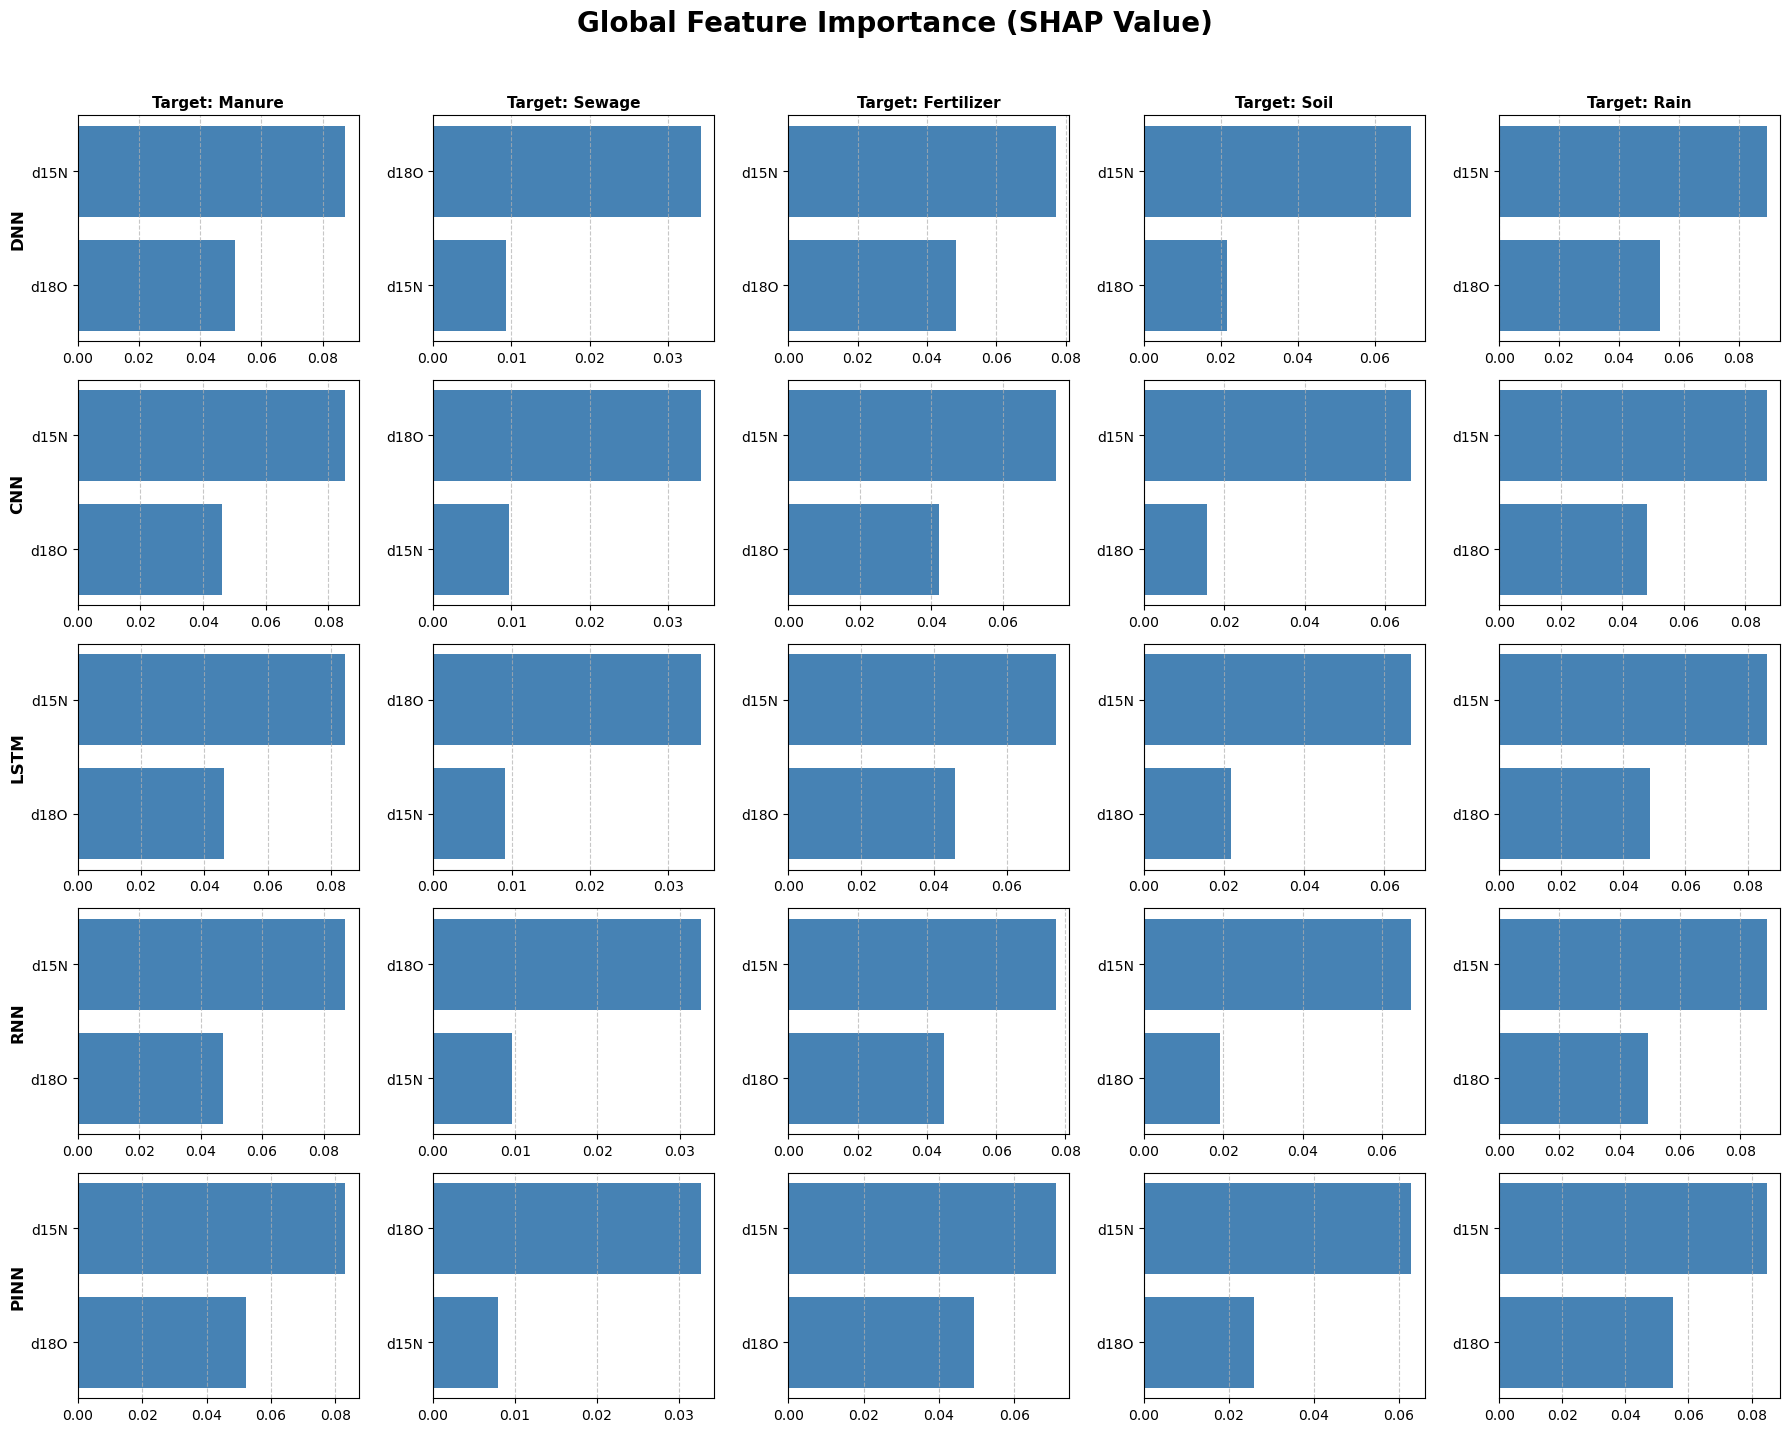

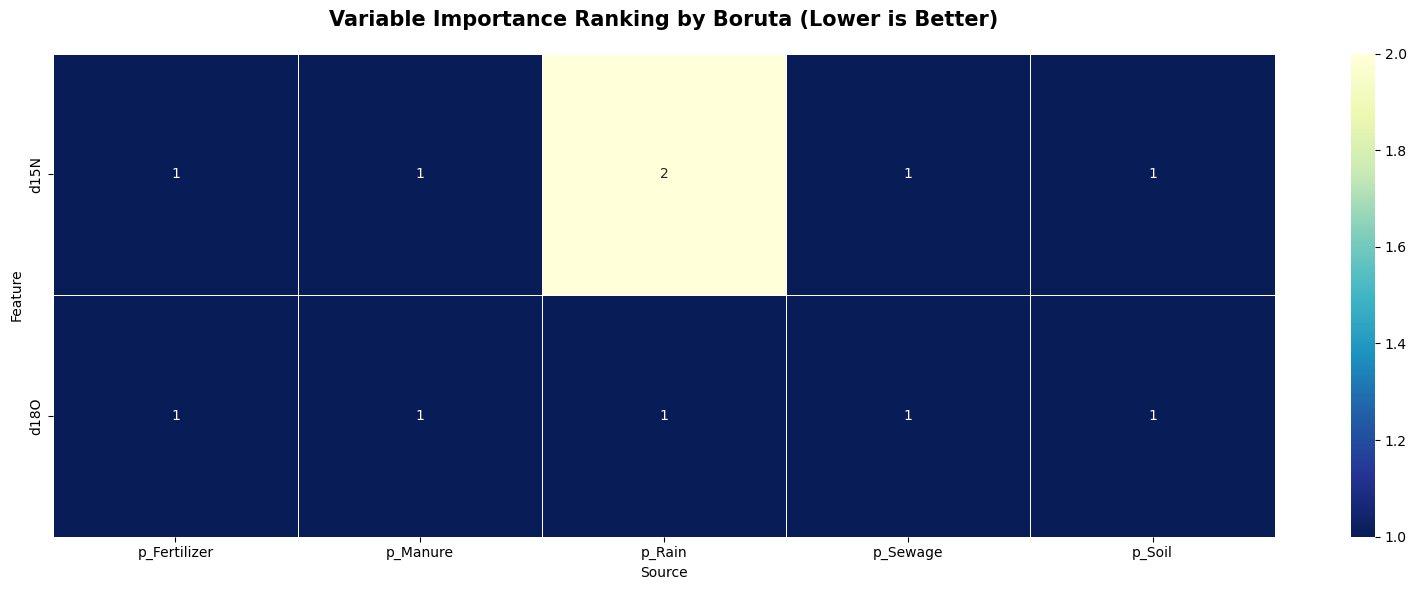

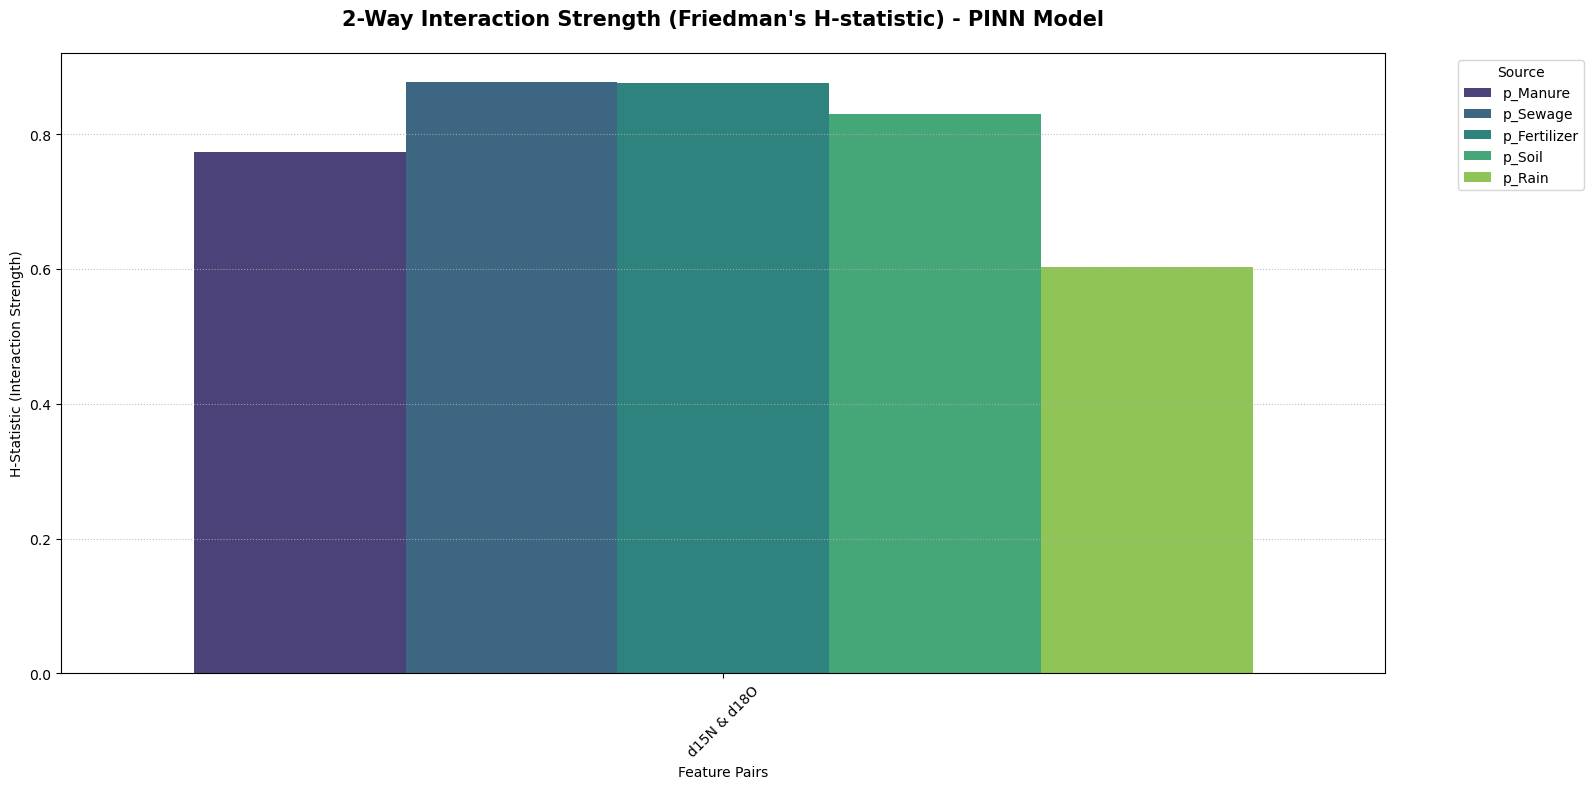

In [41]:
# =====================================================================
# [Step 5] 통합 XAI (SHAP, Boruta, H-statistic) 시각화 보강
# =====================================================================
import seaborn as sns

print("\n=== [5-V] XAI 결과 시각화 및 리포트 생성 시작 ===")

shap_df = pd.DataFrame(all_shap_results)

# ---------------------------------------------------------------------
# 1. SHAP 시각화 (기존 유지 및 보강)
# ---------------------------------------------------------------------
if not shap_df.empty:
    plt.figure(figsize=(18, 14))
    for i, m in enumerate(ai_methods):
        for j, s in enumerate(source_names):
            ax = plt.subplot(len(ai_methods), len(source_names), i * len(source_names) + j + 1)
            subset = shap_df[(shap_df['Method'] == m) & (shap_df['Source'] == s)]
            subset = subset.sort_values(by="SHAP_Importance")
            
            ax.barh(subset['Feature'], subset['SHAP_Importance'], color='steelblue')
            if i == 0:
                ax.set_title(f"Target: {s.replace('p_', '')}", fontsize=11, fontweight='bold')
            if j == 0:
                ax.set_ylabel(m, fontsize=12, fontweight='bold')
            ax.grid(axis='x', linestyle='--', alpha=0.7)

    plt.suptitle("Global Feature Importance (SHAP Value)", fontsize=20, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.savefig("XAI_1_SHAP_Comparison.png", dpi=200)
    print("-> [저장 완료] XAI_1_SHAP_Comparison.png")

# ---------------------------------------------------------------------
# 2. Boruta Algorithm 시각화 (변수 중요도 랭킹)
# ---------------------------------------------------------------------
if not boruta_df.empty:
    plt.figure(figsize=(16, 6))
    # 랭킹이 낮을수록(1에 가까울수록) 중요한 변수이므로 역순으로 시각화하거나 랭킹값 표시
    boruta_plot_df = boruta_df.copy()
    
    # Heatmap 형태로 시각화 (변수 vs 오염원)
    boruta_pivot = boruta_plot_df.pivot(index="Feature", columns="Source", values="Boruta_Ranking")
    
    sns.heatmap(boruta_pivot, annot=True, cmap="YlGnBu_r", fmt=".0f", linewidths=.5)
    plt.title("Variable Importance Ranking by Boruta (Lower is Better)", fontsize=15, pad=20, fontweight='bold')
    plt.tight_layout()
    plt.savefig("XAI_2_Boruta_Ranking.png", dpi=200)
    print("-> [저장 완료] XAI_2_Boruta_Ranking.png")

# ---------------------------------------------------------------------
# 3. H-statistic 시각화 (2-Way Interaction 강도)
# ---------------------------------------------------------------------
if not h_stat_df.empty:
    plt.figure(figsize=(16, 8))
    
    # 오염원별로 상호작용 강도를 비교할 수 있도록 Bar Chart 생성
    sns.barplot(data=h_stat_df, x="Feature_Pair", y="H_Statistic", hue="Source", palette="viridis")
    
    plt.title("2-Way Interaction Strength (Friedman's H-statistic) - PINN Model", fontsize=15, pad=20, fontweight='bold')
    plt.ylabel("H-Statistic (Interaction Strength)")
    plt.xlabel("Feature Pairs")
    plt.xticks(rotation=45)
    plt.legend(title="Source", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle=':', alpha=0.8)
    
    plt.tight_layout()
    plt.savefig("XAI_3_H_Statistic_Interaction.png", dpi=200)
    print("-> [저장 완료] XAI_3_H_Statistic_Interaction.png")

print("\n[최종 결과] 모든 XAI 시각화 파일이 현재 디렉토리에 저장되었습니다.")